In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [ ]:
# Loading Data Files

DATA_PATH = Path("../data")
btc_5min = pd.read_csv(DATA_PATH / "btc_5min_binance_2021_2025.csv")

print("5-min data shape:", btc_5min.shape)

5-min data shape: (525675, 15)


In [3]:
btc_5min.head(3)
# open_time_utc and close_time_utc used in this are very proper and already human-readable

,open_time_ms,open,high,low,close,volume,close_time_ms,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,open_time_utc,close_time_utc,price_close
0,1609459200000,28923.63,29017.50,28913.12,28975.65,182.889878,1609459499999,5.300787e+06,5614,80.029129,2.319247e+06,0,2021-01-01 00:00:00+00:00,2021-01-01 00:04:59.999000+00:00,28975.65
1,1609459500000,28975.65,28979.53,28846.28,28858.94,214.568104,1609459799999,6.201532e+06,4928,113.761331,3.287213e+06,0,2021-01-01 00:05:00+00:00,2021-01-01 00:09:59.999000+00:00,28858.94
2,1609459800000,28858.94,28883.20,28690.17,28752.80,442.619587,1609460099999,1.273741e+07,8776,199.913764,5.753595e+06,0,2021-01-01 00:10:00+00:00,2021-01-01 00:14:59.999000+00:00,28752.80


In [4]:
btc_5min.columns
# colnames to check

Index(['open_time_ms', 'open', 'high', 'low', 'close', 'volume',
       'close_time_ms', 'quote_asset_volume', 'num_trades',
       'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore',
       'open_time_utc', 'close_time_utc', 'price_close'],
      dtype='object')

In [5]:
# To create candlesticks later, let's start by creating an open time index

# Convert open_time_utc to datetime (timezone-aware)
btc_5min['open_time_utc'] = pd.to_datetime(btc_5min['open_time_utc'])
# Create a clean, timezone-naive index column for modelling + merges
btc_5min['open_time_index'] = btc_5min['open_time_utc'].dt.tz_convert(None)
# Sort using the index column (ensures chronological order)
btc_5min = btc_5min.sort_values('open_time_index')
# Set index
btc_5min = btc_5min.set_index('open_time_index')
# Drop exchange artifact column
btc_5min = btc_5min.drop(columns=['ignore'])

btc_5min.head(3)


,open_time_ms,open,high,low,close,volume,close_time_ms,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,open_time_utc,close_time_utc,price_close
open_time_index,,,,,,,,,,,,,,
2021-01-01 00:00:00,1609459200000,28923.63,29017.50,28913.12,28975.65,182.889878,1609459499999,5.300787e+06,5614,80.029129,2.319247e+06,2021-01-01 00:00:00+00:00,2021-01-01 00:04:59.999000+00:00,28975.65
2021-01-01 00:05:00,1609459500000,28975.65,28979.53,28846.28,28858.94,214.568104,1609459799999,6.201532e+06,4928,113.761331,3.287213e+06,2021-01-01 00:05:00+00:00,2021-01-01 00:09:59.999000+00:00,28858.94
2021-01-01 00:10:00,1609459800000,28858.94,28883.20,28690.17,28752.80,442.619587,1609460099999,1.273741e+07,8776,199.913764,5.753595e+06,2021-01-01 00:10:00+00:00,2021-01-01 00:14:59.999000+00:00,28752.80


In [6]:
# Quick checks

print("Duplicates:", btc_5min.index.duplicated().sum())
print("Sorted:", btc_5min.index.is_monotonic_increasing)
print("Index range:", btc_5min.index.min(), "to", btc_5min.index.max())
print("Most common step:", btc_5min.index.to_series().diff().value_counts().head())
# most common is 5 minutes but we have 4 other steps that are bigger, looks like missing data
# still very clean considering that it is high-freq data

Duplicates: 0
Sorted: True
Index range: 2021-01-01 00:00:00 to 2025-12-31 23:55:00
Most common step: 0 days 00:05:00    525667
0 days 04:45:00         1
0 days 01:20:00         1
0 days 01:35:00         1
0 days 02:05:00         1
Name: open_time_index, dtype: int64


In [7]:
# inspecting gaps

gaps = btc_5min.index.to_series().diff()
abnormal_gaps = gaps[gaps != pd.Timedelta(minutes=5)]
print(abnormal_gaps)

# The high-frequency Binance dataset exhibits near-continuous trading, with only 7 minor timestamp discontinuities over the 2021–2025 sample period.
# Important for later: when computing daily realised variance, check per-day bar count -- if a day has <288 bars, maybe drop it from RV calculation?

open_time_index
2021-01-01 00:00:00               NaT
2021-02-11 05:00:00   0 days 01:20:00
2021-03-06 03:30:00   0 days 01:35:00
2021-04-20 04:30:00   0 days 02:35:00
2021-04-25 08:45:00   0 days 04:45:00
2021-08-13 06:30:00   0 days 04:35:00
2021-09-29 09:00:00   0 days 02:05:00
2023-03-24 14:00:00   0 days 01:25:00
Name: open_time_index, dtype: timedelta64[ns]


In [8]:
# checking bars per day

bars_per_day = btc_5min.groupby(btc_5min.index.date).size()
print(bars_per_day.describe())
print("Days with < 288 bars:", (bars_per_day < 288).sum())

# this matters because for days with lower numbe rof bars (eg: the 4h 45m gap), the RV would be underestimated

count    1826.000000
mean      287.883352
std         2.133638
min       232.000000
25%       288.000000
50%       288.000000
75%       288.000000
max       288.000000
dtype: float64
Days with < 288 bars: 7


In [9]:
incomplete_days = bars_per_day[bars_per_day < 288]
print(incomplete_days)
# to take note of the few days with a few missing bars (might wanna drop them from RV estimations later)

2021-02-11    273
2021-03-06    270
2021-04-20    258
2021-04-25    232
2021-08-13    234
2021-09-29    264
2023-03-24    272
dtype: int64


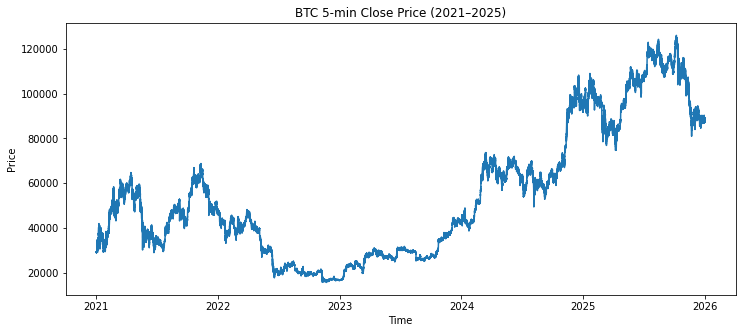

In [10]:
# Simple Visualisations
# Quick Sanity Check: Plotting Price Data over Time
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(btc_5min['close'])
plt.title("BTC 5-min Close Price (2021–2025)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [13]:
# 5 years worth of data for candlestick would be completely unreadable, let's start with a sample week

sample = btc_5min.loc["2021-02-01":"2021-02-07"]

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/mplfinance/_arg_validators.py:94: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  category=UserWarning)


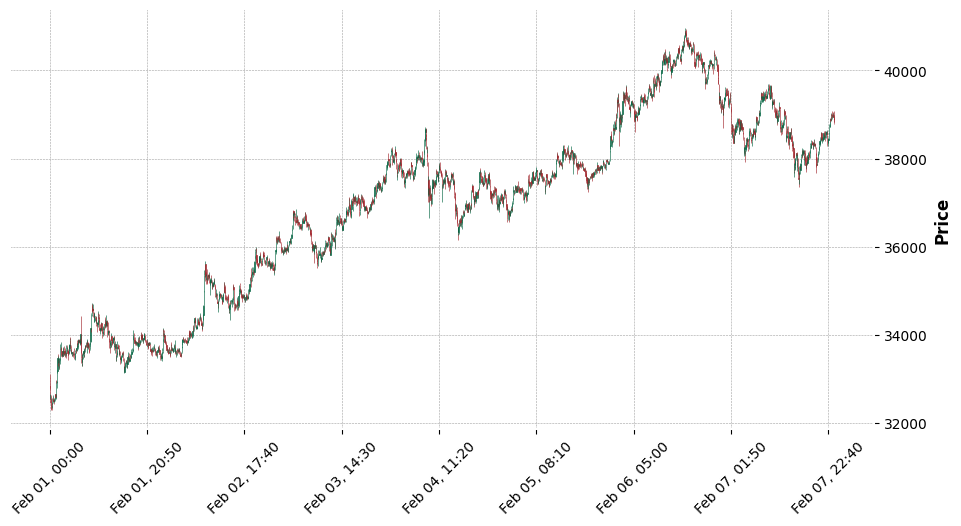

In [ ]:
# using mplfinance for magnification
import mplfinance as mpf

mpf.plot(sample[['open','high','low','close','volume']],
         type='candle',
         volume=False,
         style='charles',
         figsize=(12,6))

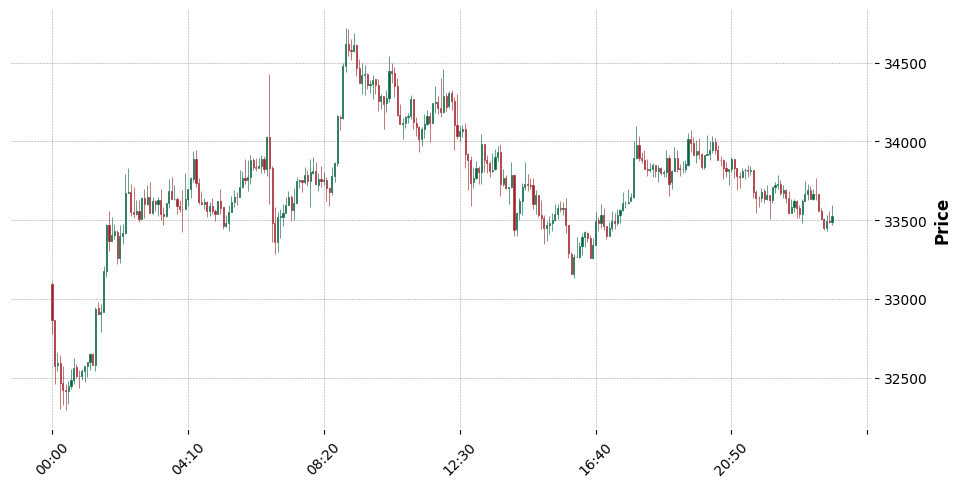

In [21]:
# let's move closer to say 2 days for our sample
sample_2 = btc_5min.loc["2021-02-01":"2021-02-01"] 

mpf.plot(sample_2[['open','high','low','close','volume']],
         type='candle',
         volume=False,
         style='charles',
         figsize=(12,6))

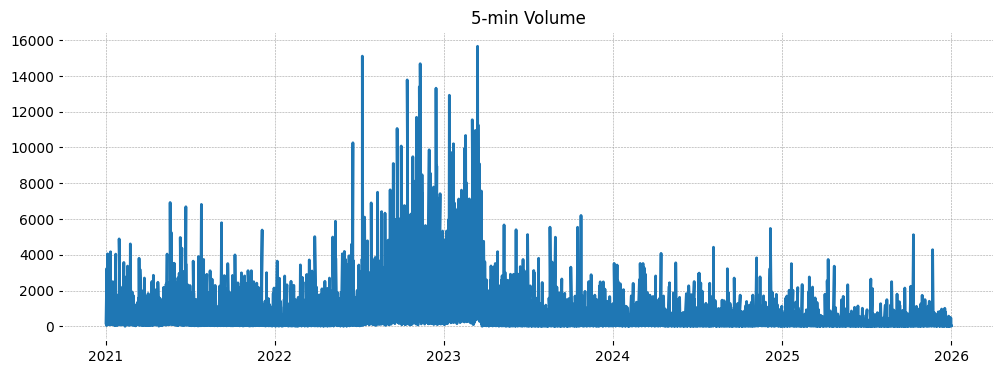

In [ ]:
# Also a volume plot (for whole data) because volume anomalies often coincide with volatility spikes.
plt.figure(figsize=(12,4))
plt.plot(btc_5min['volume'])
plt.title("5-min Volume")
plt.show()

# there is no zero volume regions but we sure do see some volume (implying volatility) spikes

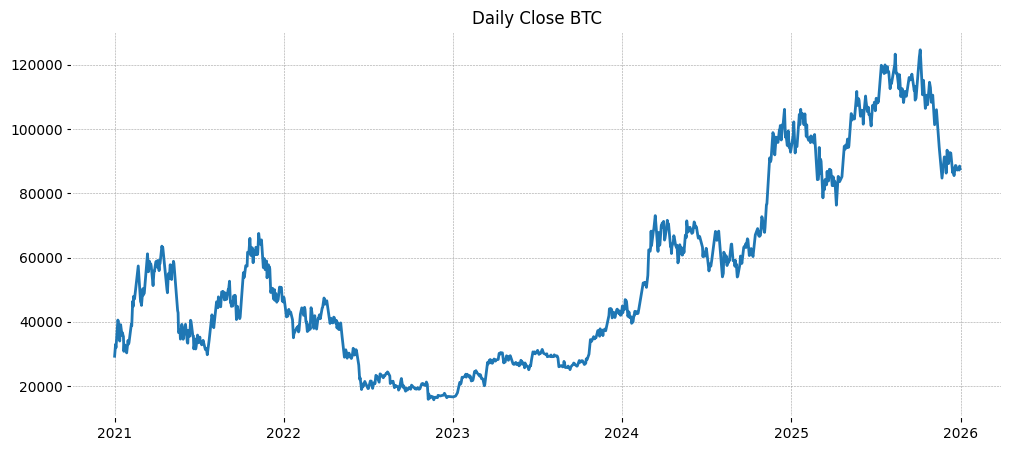

In [ ]:
# 5 mins across 5 years is a bit too high-freq
# Daily Resampled Close (to get a Cleaner Long-Term View)
daily_close = btc_5min['close'].resample('D').last()

plt.figure(figsize=(12,5))
plt.plot(daily_close)
plt.title("Daily Close BTC")
plt.show()

# We are able to clearly see some macro trends we already know of eg: 2021 bull run, 2022 crash, 2023–2024 recovery

In [ ]:
# quick desc stats
btc_5min[['open','high','low','close','volume']].describe()

# Summary statistics confirm realistic BTC price dynamics over 2021–2025, with substantial dispersion reflecting major market cycles. 
# Observed min/max levels align with historical extremes, and volume exhibits expected right-skewness typical of crypto trading activity. No obvious anomalies detected

,open,high,low,close,volume
count,525675.000000,525675.000000,525675.000000,525675.000000,525675.000000
mean,54393.045110,54450.027985,54335.181897,54393.154202,259.134308
std,29463.027035,29481.290065,29444.182309,29463.043435,452.664627
min,15590.570000,15633.310000,15476.000000,15593.580000,0.000000
25%,29403.760000,29417.380000,29390.000000,29403.815000,52.350675
50%,46486.160000,46557.310000,46410.000000,46486.820000,111.304720
75%,69074.605000,69130.000000,69011.230000,69074.960000,268.399132
max,126011.180000,126199.630000,125868.130000,126011.180000,15659.934840


In [24]:
(btc_5min['volume'] == 0).sum()

31

In [ ]:
zero_vol = btc_5min[btc_5min['volume'] == 0]
print(zero_vol.shape)
zero_vol.head()

(31, 14)


,open_time_ms,open,high,low,close,volume,close_time_ms,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,open_time_utc,close_time_utc,price_close
open_time_index,,,,,,,,,,,,,,
2021-02-11 02:20:00,1613010000000,44582.07,44582.07,44582.07,44582.07,0.0,1613010299999,0.0,0,0.0,0.0,2021-02-11 02:20:00+00:00,2021-02-11 02:24:59.999000+00:00,44582.07
2021-02-11 02:25:00,1613010300000,44582.07,44582.07,44582.07,44582.07,0.0,1613010599999,0.0,0,0.0,0.0,2021-02-11 02:25:00+00:00,2021-02-11 02:29:59.999000+00:00,44582.07
2021-02-11 02:30:00,1613010600000,44582.07,44582.07,44582.07,44582.07,0.0,1613010899999,0.0,0,0.0,0.0,2021-02-11 02:30:00+00:00,2021-02-11 02:34:59.999000+00:00,44582.07
2021-02-11 02:35:00,1613010900000,44582.07,44582.07,44582.07,44582.07,0.0,1613011199999,0.0,0,0.0,0.0,2021-02-11 02:35:00+00:00,2021-02-11 02:39:59.999000+00:00,44582.07
2021-02-11 02:40:00,1613011200000,44582.07,44582.07,44582.07,44582.07,0.0,1613011499999,0.0,0,0.0,0.0,2021-02-11 02:40:00+00:00,2021-02-11 02:44:59.999000+00:00,44582.07


In [27]:
# to see only timestamps of zero vol data
zero_vol.index.tolist()

[Timestamp('2021-02-11 02:20:00'),
 Timestamp('2021-02-11 02:25:00'),
 Timestamp('2021-02-11 02:30:00'),
 Timestamp('2021-02-11 02:35:00'),
 Timestamp('2021-02-11 02:40:00'),
 Timestamp('2021-02-11 02:45:00'),
 Timestamp('2021-02-11 02:50:00'),
 Timestamp('2021-02-11 02:55:00'),
 Timestamp('2021-02-11 03:00:00'),
 Timestamp('2021-02-11 03:05:00'),
 Timestamp('2021-02-11 03:10:00'),
 Timestamp('2021-02-11 03:15:00'),
 Timestamp('2021-02-11 03:20:00'),
 Timestamp('2021-02-11 03:25:00'),
 Timestamp('2021-02-11 03:30:00'),
 Timestamp('2021-02-11 03:35:00'),
 Timestamp('2021-02-11 03:40:00'),
 Timestamp('2023-03-24 11:30:00'),
 Timestamp('2023-03-24 11:35:00'),
 Timestamp('2023-03-24 11:40:00'),
 Timestamp('2023-03-24 11:45:00'),
 Timestamp('2023-03-24 11:50:00'),
 Timestamp('2023-03-24 11:55:00'),
 Timestamp('2023-03-24 12:00:00'),
 Timestamp('2023-03-24 12:05:00'),
 Timestamp('2023-03-24 12:10:00'),
 Timestamp('2023-03-24 12:15:00'),
 Timestamp('2023-03-24 12:20:00'),
 Timestamp('2023-03-

In [ ]:
# check to see if these are occuring in clusters
zero_vol.index.to_series().diff().value_counts()
# 29 of the zero-volume candles occur exactly 5 minutes apart meaning we have one cluster of zero-volume candles forming a block.

0 days 00:05:00      29
771 days 07:50:00     1
Name: open_time_index, dtype: int64

In [ ]:
# checking if flat prices in these zero_vol rows - YES meaning just a no-trade candle
zero_vol[['open','high','low','close']]

,open,high,low,close
open_time_index,,,,
2021-02-11 02:20:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:25:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:30:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:35:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:40:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:45:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:50:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 02:55:00,44582.07,44582.07,44582.07,44582.07
2021-02-11 03:00:00,44582.07,44582.07,44582.07,44582.07


In [30]:
# Moving onto prelim construction of log returns
import numpy as np

btc_5min['log_return'] = np.log(btc_5min['close']).diff()
btc_5min = btc_5min.dropna(subset=['log_return'])

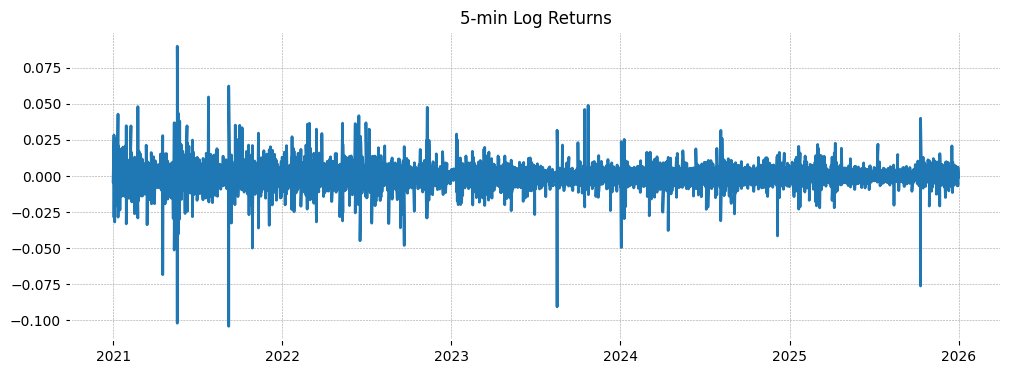

In [ ]:
# Plotting log returns
# Our expectation for log returns should be that they: look like white noise + volatility clustering + no trend
plt.figure(figsize=(12,4))
plt.plot(btc_5min['log_return'])
plt.title("5-min Log Returns")
plt.show()

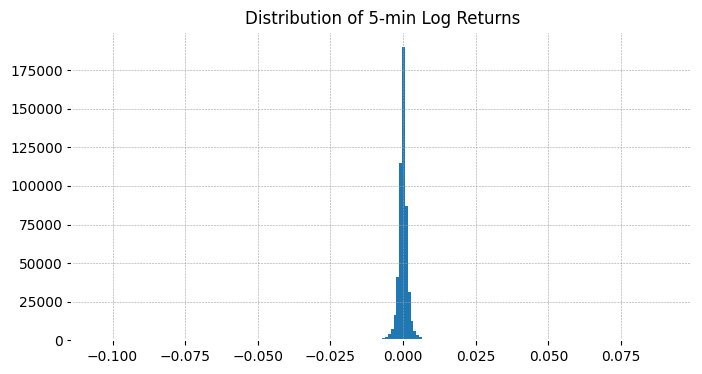

In [ ]:
# Now plotting the distribution of returns
plt.figure(figsize=(8,4))
plt.hist(btc_5min['log_return'], bins=200)
plt.title("Distribution of 5-min Log Returns")
plt.show()

# # The 5min log returns are highly concentrated near zero reflecting small incremental price changes at high frequency.
# The presence of fat tails suggests elevated kurtosis and a higher probability of extreme price movements, consistent with volatility clustering in BTC.

In [34]:
# numeric diagnosis
print(btc_5min['log_return'].describe())
print(btc_5min['log_return'].skew())
print(btc_5min['log_return'].kurt())

count    525674.000000
mean          0.000002
std           0.001980
min          -0.104145
25%          -0.000722
50%           0.000000
75%           0.000727
max           0.089866
Name: log_return, dtype: float64
-0.5210197237359692
101.61636553877159


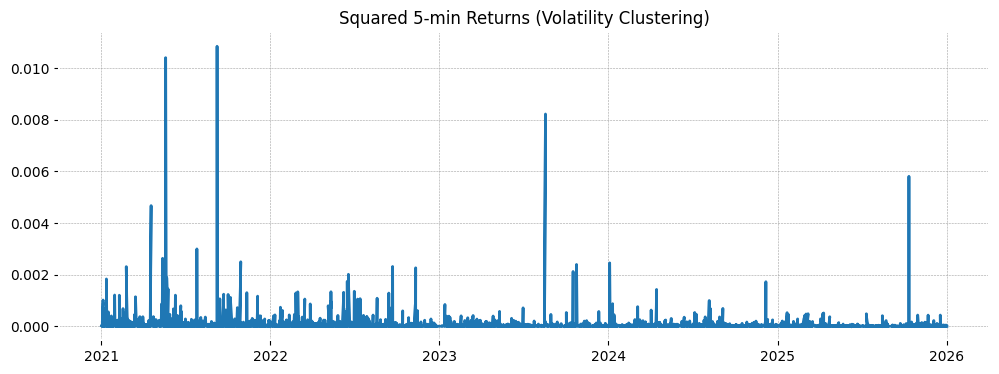

In [ ]:
# Plotting squared returns
plt.figure(figsize=(12,4))
plt.plot(btc_5min['log_return']**2)
plt.title("Squared 5-min Returns (Volatility Clustering)")
plt.show()

# we see calm periods and explosive bursts ( alil bit) suggesting that dataset exhibits volatility clustering

## Volatility Clustering means that
# Large shocks tend to be followed by large shocks.
# Small shocks tend to be followed by small shocks.
# This is one of the most important stylized facts in financial time series.

In [ ]:
# we can do ACFs after this if needed